#### **Important code from previous notebook - Preprocessing**

In [11]:
# Reloaded Data

import pandas as pd

df = pd.read_csv("../data/raw/European_Bank_data.csv")

In [12]:
df = df.drop(['CustomerId', 'Surname', 'Year'], axis=1)

# As we identified useless columns, by useless we mean that every column, Cannot help the model in any situation so we dropped them using Pandas df.drop() method.

In [13]:
# Feature Engineering

df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

df["ProductDensity"] = df["NumOfProducts"] / (df["Tenure"] + 1)

df["EngagementProduct"] = df["IsActiveMember"] * df["NumOfProducts"]

df["AgeTenureInteraction"] = df["Age"] * df["Tenure"]

In [14]:
# Separated Independent and dependent Variables :

X = df.drop('Exited', axis = 1)
y = df['Exited']

X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenureInteraction
0,619,France,Female,42,2,0.00,1,1,1,101348.88,0.000000,0.333333,1,84
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0.744670,0.500000,1,41
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1.401362,0.333333,0,336
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0.000000,1.000000,0,39
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,1.587035,0.333333,1,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0.000000,0.333333,0,195
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0.564102,0.090909,1,350
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,0.000000,0.125000,1,252
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,0.808222,0.500000,0,126


In [15]:
# Feature Encoding

X = pd.get_dummies(X, drop_first=True)

# Encoded categorical variables - By using pd.get_dummies(), for one-hot encoding, transforms non-numeric data (like strings or categories) into a numerical format usually binary 0-1, or Boolean True-False.

In [16]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2,
    stratify = y, random_state = 26)

# We split the dataset into training and testing sets (80/20), while keeping the churn distribution consistent, so the model can learn on one part and be fairly evaluated on unseen data.

In [17]:
# train_scaled

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Imported scikit learn a machine learning library, preprocessing its module for preparing data, StandardScaler to scale features. Then we created a scaler object so that we can use fit and transform methods in the next step.

# Fit learns from data. Fit method Calculates mean of each column from training, Calculates standard deviation from training
# Transform applies scaling formula
# We can also use combined method - fit_transform that does the both at once.

In [18]:
# test_scaled
X_test_scaled = scaler.transform(X_test)

# Scaling ensures that all features contribute equally to the model by bringing them to a comparable range.
# Age → -1 to +1
# Balance → -1 to +1
# Salary → -1 to +1

#### **Final Function Call below**

In [19]:
# Train Model

from models.train import train_logistic, save_artifacts
model = train_logistic(X_train_scaled, y_train)

# Save
save_artifacts(model, scaler, X_train.columns.tolist())

Artifacts saved successfully.


/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

Loaded → Cleaned → Feature Engineering done → Encoding done → Split done → Scale done → Train done
#####  Main code ends here
---
---

#### For reference :
    X_train_scaled - Scaled features data used to train the model
    y_train - corresponding true values for X_train

    X_test - unseen feature data used for evaluation
    y_test_scaled - Scaled true values for X_test (used to compare against predictions)

---
#### **Everything from here is for experiment and Evaluation**
---

### **MODEL TRAINING - Decision Tree**
3.model_training.ipynb starts from here

#### Train model → Get probabilities → Threshold tuning → Evaluate



#### Step 1. Evaluation with DecisionTreeClassifier

Created variable and stored the model in it, Initialized the model with parameters - maximum numbers of iterations and "balanced" so that the model gives more importance to churn class and helps model not to ignore minority class

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Get probabilities
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
print(y_prob_dt)


# Threshold tuning
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_dt = (y_prob_dt >= t).astype(int)

    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_dt))
    print("Recall:", recall_score(y_test, y_pred_dt))
    print("F1:", f1_score(y_test, y_pred_dt))
    print("Confusion Matrix:", confusion_matrix(y_test, y_pred_dt))
    print("ROC_AUC :", roc_auc_score(y_test, y_prob_dt))

[0. 0. 0. ... 0. 0. 0.]

Threshold: 0.3
Precision: 0.4742990654205608
Recall: 0.4987714987714988
F1: 0.48622754491017967
Confusion Matrix: [[1368  225]
 [ 204  203]]
ROC_AUC : 0.6787642804591958

Threshold: 0.4
Precision: 0.4742990654205608
Recall: 0.4987714987714988
F1: 0.48622754491017967
Confusion Matrix: [[1368  225]
 [ 204  203]]
ROC_AUC : 0.6787642804591958

Threshold: 0.5
Precision: 0.4742990654205608
Recall: 0.4987714987714988
F1: 0.48622754491017967
Confusion Matrix: [[1368  225]
 [ 204  203]]
ROC_AUC : 0.6787642804591958

Threshold: 0.6
Precision: 0.4742990654205608
Recall: 0.4987714987714988
F1: 0.48622754491017967
Confusion Matrix: [[1368  225]
 [ 204  203]]
ROC_AUC : 0.6787642804591958


#### Step 3. Predict, it predicts in binary, 0 No churn, 1 churn.

In [12]:
y_pred = model.predict(X_test_scaled)
y_pred


/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([0, 0, 0, ..., 0, 0, 1], shape=(2000,))

**PAY ATTENTION -**

**Checked probabilities using model.predict_proba(), which returns the probability of each class (0 = not churn, 1 = churn) for every customer.**

**Each row contains two values: [prob_not_churn, prob_churn].**

**We extract the churn probability using [:, 1], which gives the likelihood of a customer leaving.**

**y_pred provides final decisions (0 = no churn, 1 = churn) based on a default threshold of 0.5.**

**y_prob provides probability scores (e.g., 0.30, 0.72), indicating how likely a customer is to churn.**

**These probabilities are more informative, as they allow better evaluation, threshold tuning, and help prioritize high-risk customers in real-world scenarios.**

**Example:**

    0.56 → moderate chance of churn
    0.95 → very high chance of churn
    0.20 → low risk customer

#### Step 4. Get probabilities

In [13]:
y_prob = model.predict_proba(X_test_scaled)[:, 1] # we specify that we only want churn 1.
y_prob

# model.predict_Proba - gives us percentage of probability churn. So if y_prob = 0.82, that means the model estimates about 82% churn likelihood for that customer.

/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([0.29370449, 0.4549114 , 0.19968966, ..., 0.49396007, 0.3421773 ,
       0.61516347], shape=(2000,))

#### Step 5. Quick check, for Debugging habit.

In [14]:
y_prob[:10]

array([0.29370449, 0.4549114 , 0.19968966, 0.34864333, 0.10938064,
       0.39355278, 0.38725826, 0.40883775, 0.73320704, 0.16150949])

Each value in the output above represents the probability of churn for a customer, allowing us to assess risk levels instead of just binary predictions.

---
---

### **Done with getting our numbers with DecsionTreeClassifier**

---
---

#### Step 6. Model Evaluation with
## Model 2 - Logistic Regression

- Accuracy: Percentage of total predictions the model got correct.
- Precision: Out of all predicted churn customers, how many actually churned.
- Recall: Out of all actual churn customers, how many the model correctly identified.
- F1 Score: Balance between precision and recall, useful when classes are imbalanced.
- ROC-AUC: Measures how well the model separates churn vs non-churn across all thresholds.
- Confusion Matrix: A 2X2 matrix table that shows the number of correct and incorrect predictions by comparing actual vs predicted classes (TN, FP, FN, TP).

- F-beta Score: A metric that measures model performance by combining precision and recall, with adjustable emphasis (beta) to prioritize recall or precision.

In [15]:
from models.train import train_logistic
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Train
model = train_logistic(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))



# Model Improvement  - Threshold Tuning + Optimization.**
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)  # Compare each probability with current threshold

    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("Recall:", recall_score(y_test, y_pred_custom))
    print("F1:", f1_score(y_test, y_pred_custom))
    print("Confusion Matrix:" , confusion_matrix(y_test, y_pred_custom))


# - Accuracy: Percentage of total predictions the model got correct.
# - Precision: Out of all predicted churn customers, how many actually churned.
# - Recall: Out of all actual churn customers, how many the model correctly identified.
# - F1 Score: Balance between precision and recall, useful when classes are imbalanced.
# - ROC-AUC: Measures how well the model separates churn vs non-churn across all thresholds.
# - Confusion Matrix: A 2X2 matrix table that shows the number of correct and incorrect predictions by comparing actual vs predicted classes (TN, FP, FN, TP).

Accuracy: 0.7095
Precision: 0.38082191780821917
Recall: 0.683046683046683
F1 Score: 0.4890061565523307
ROC-AUC: 0.7715203647407036
Confusion Matrix: [[1141  452]
 [ 129  278]]

Threshold: 0.3
Precision: 0.27074235807860264
Recall: 0.914004914004914
F1: 0.41774284110050536
Confusion Matrix: [[ 591 1002]
 [  35  372]]

Threshold: 0.4
Precision: 0.32463768115942027
Recall: 0.8255528255528255
F1: 0.46601941747572817
Confusion Matrix: [[894 699]
 [ 71 336]]

Threshold: 0.5
Precision: 0.38082191780821917
Recall: 0.683046683046683
F1: 0.4890061565523307
Confusion Matrix: [[1141  452]
 [ 129  278]]

Threshold: 0.6
Precision: 0.4581673306772908
Recall: 0.5651105651105651
F1: 0.506050605060506
Confusion Matrix: [[1321  272]
 [ 177  230]]


/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

From the output above noticed that the baseline Logistic Regression achieved a ROC-AUC of 0.77 and recall of ~0.69, indicating good ability to identify churn customers.

#### Logistic Regression – Evaluation Default Threshold = 0.5

| Metric | Value   | Interpretation |
|--------|---------|----------------|
| Accuracy | 0.70 🟡 | OK (can be misleading due to imbalance) |
| Precision | 0.38 🔴 | Low — many false positives |
| Recall | 0.68 🟡 | Decent — captures most churn customers |
| F1 Score | 0.48 🔴 | Weak — poor balance |
| ROC-AUC | 0.77 🟢 | Good — strong separation ability |
| F2 Score | 0.58 🟡 | Moderate — decent recall focus |


However, precision was lower, suggesting room for reducing false positives. We will have to perform threshold tuning to improve the model.

A good model minimizes both false positives and false negatives, but in churn prediction, reducing false negatives is more critical as it directly impacts customer retention.

So Far

We trained a Logistic Regression model to predict churn probabilities, converted them into predictions using a default threshold of 0.5, and evaluated performance using multiple metrics to understand both accuracy and class-wise behavior.

---

#### **Step 7. Model Improvement  - Threshold Tuning + Optimization.**

Compare multiple thresholds, to get the best out of them.

In [16]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)  # Compare each probability with current threshold

    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("Recall:", recall_score(y_test, y_pred_custom))
    print("F1:", f1_score(y_test, y_pred_custom))
    print("Confusion Matrix:" , confusion_matrix(y_test, y_pred_custom))


# - Accuracy: Percentage of total predictions the model got correct.
# - Precision: Out of all predicted churn customers, how many actually churned.
# - Recall: Out of all actual churn customers, how many the model correctly identified.
# - F1 Score: Balance between precision and recall, useful when classes are imbalanced.
# - ROC-AUC: Measures how well the model separates churn vs non-churn across all thresholds.
# - Confusion Matrix: A 2X2 matrix table that shows the number of correct and incorrect predictions by comparing actual vs predicted classes (TN, FP, FN, TP).



Threshold: 0.3
Precision: 0.27074235807860264
Recall: 0.914004914004914
F1: 0.41774284110050536
Confusion Matrix: [[ 591 1002]
 [  35  372]]

Threshold: 0.4
Precision: 0.32463768115942027
Recall: 0.8255528255528255
F1: 0.46601941747572817
Confusion Matrix: [[894 699]
 [ 71 336]]

Threshold: 0.5
Precision: 0.38082191780821917
Recall: 0.683046683046683
F1: 0.4890061565523307
Confusion Matrix: [[1141  452]
 [ 129  278]]

Threshold: 0.6
Precision: 0.4581673306772908
Recall: 0.5651105651105651
F1: 0.506050605060506
Confusion Matrix: [[1321  272]
 [ 177  230]]


#### Closely examined the thresholds  we got as a result from the above output


#### Metric Interpretation
| Range        | Interpretation |
|--------------|---------------|
| > 0.70       | 🟢 Good        |
| 0.50 – 0.70  | 🟡 Moderate    |
| < 0.50       | 🔴 Weak        |

#### Logistic Regression  - Threshold Evaluation
| Threshold | Precision | Recall | F1 Score | F2 Score | FN (Missed Churn) | FP (False Alarm) |
|----------|----------|--------|---------|---------|------------------|------------------|
| 0.3 | 0.27 🔴 | 0.92 🟢 | 0.42 🔴 | 0.62 🟡 | 32  🟢 | 1007 🔴 |
| 0.4 | 0.32 🔴 | 0.83 🟢 | 0.47 🔴 | 0.63 🟡 | 69  🟡 | 706  🔴 |
| 0.5 | 0.38 🟡 | 0.69 🟡 | 0.49 🔴 | 0.60 🟡 | 125 🔴 | 453  🟡 |
| 0.6 | 0.46 🟡 | 0.56 🟡 | 0.51 🟢 | 0.54 🔴 | 177 🔴 | 271  🟡 |

**Metrics :**
- Accuracy: Percentage of total predictions the model got correct.
- Precision: Out of all predicted churn customers, how many actually churned.
- Recall: Out of all actual churn customers, how many the model correctly identified.
- F1 Score: Balance between precision and recall, useful when classes are imbalanced.
- ROC-AUC: Measures how well the model separates churn vs non-churn across all thresholds.
- Confusion Matrix: A table that shows the number of correct and incorrect predictions by comparing actual vs predicted classes (TN, FP, FN, TP).
- F-beta Score: A metric that measures model performance by combining precision and recall, with adjustable emphasis (beta) to prioritize recall or precision.

##### Observations

- Threshold 0.3 achieves the highest recall (0.92), meaning almost all churn customers are identified, but at the cost of extremely high false positives (1007)
- Threshold 0.4 provides a strong balance with high recall (0.83) and improved F2 score, making it suitable when minimizing missed churn is important
- Threshold 0.5 offers a moderate balance but misses more churn customers (FN = 125)
- Threshold 0.6 achieves the highest F1 score (0.51), indicating the best statistical balance, but recall drops significantly, increasing missed churn cases

##### Business Insight

- Lower thresholds (0.3, 0.4) → aggressive strategy (catch more churn, many false alarms)
- Higher thresholds (0.5, 0.6) → conservative strategy (fewer false alarms, miss more churn)

##### Final Decision

- If business prioritizes minimizing churn loss → choose threshold = 0.4
- If business prefers balanced performance → choose threshold = 0.6

---
---



## Evaluating with Model 2 - Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create model object
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


In [18]:
# train model
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_pred


array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [20]:
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_prob

array([0.2 , 0.12, 0.01, ..., 0.02, 0.05, 0.04], shape=(2000,))

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, fbeta_score

# evaluation for Random Forest
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("F2 Score:", fbeta_score(y_test, rf_pred, beta=2))

# - Accuracy: Percentage of total predictions the model got correct.
# - Precision: Out of all predicted churn customers, how many actually churned.
# - Recall: Out of all actual churn customers, how many the model correctly identified.
# - F1 Score: Balance between precision and recall, useful when classes are imbalanced.
# - ROC-AUC: Measures how well the model separates churn vs non-churn across all thresholds.
# - Confusion Matrix: A 2X2 matrix table that shows the number of correct and incorrect predictions by comparing actual vs predicted classes (TN, FP, FN, TP).
#
# - F-beta Score: A metric that measures model performance by combining precision and recall, with adjustable emphasis (beta) to prioritize recall or precision.


# Evaluation with Multiple Thresholds
thresholds = [0.3, 0.4, 0.5, 0.6]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, fbeta_score

for t in thresholds:
    rf_pred_custom = (rf_prob >= t).astype(int)

    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, rf_pred_custom))
    print("Precision:", precision_score(y_test, rf_pred_custom))
    print("Recall:", recall_score(y_test, rf_pred_custom))
    print("F1:", f1_score(y_test, rf_pred_custom))
    print("F2:", fbeta_score(y_test, rf_pred_custom, beta=2))
    print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_custom))

Accuracy: 0.8615
Precision: 0.7620967741935484
Recall: 0.4643734643734644
F1 Score: 0.5770992366412214
ROC-AUC: 0.8520315384722164
Confusion Matrix:
 [[1534   59]
 [ 218  189]]
F2 Score: 0.503731343283582

Threshold: 0.3
Accuracy: 0.8265
Precision: 0.5627615062761506
Recall: 0.6609336609336609
F1: 0.607909604519774
F2: 0.6386514719848053
Confusion Matrix:
 [[1384  209]
 [ 138  269]]

Threshold: 0.4
Accuracy: 0.8475
Precision: 0.646551724137931
Recall: 0.5528255528255528
F1: 0.5960264900662252
F2: 0.569331983805668
Confusion Matrix:
 [[1470  123]
 [ 182  225]]

Threshold: 0.5
Accuracy: 0.86
Precision: 0.7432950191570882
Recall: 0.47665847665847666
F1: 0.5808383233532934
F2: 0.513499205929063
Confusion Matrix:
 [[1526   67]
 [ 213  194]]

Threshold: 0.6
Accuracy: 0.861
Precision: 0.8274111675126904
Recall: 0.4004914004914005
F1: 0.5397350993377483
F2: 0.4465753424657534
Confusion Matrix:
 [[1559   34]
 [ 244  163]]


#### Random Forest – Model Evaluation
| Metric | Value | Interpretation |
|--------|------|----------------|
| Accuracy | 0.86 🟢 | High overall correctness, but less meaningful due to class imbalance |
| Precision | 0.77 🟢 | Strong — most predicted churn customers are actually churn |
| Recall | 0.46 🔴 | Low — many actual churn customers are missed |
| F1 Score | 0.58 🟡 | Moderate balance between precision and recall |
| ROC-AUC | 0.86 🟢 | Very good ability to distinguish churn vs non-churn |
| F2 Score | 0.50 🟡 | Moderate — recall still not strong enough for churn-focused objective |

#### Confusion Matrix Analysis
| Component | Value | Interpretation |
|----------|------|----------------|
| True Negatives (TN) | 1537 🟢 | Correctly predicted non-churn customers |
| False Positives (FP) | 56 🟢 | Low false alarms — good precision |
| False Negatives (FN) | 219 🔴 | High missed churn — major business concern |
| True Positives (TP) | 188 🟡 | Moderate number of correctly identified churn customers |


#### Error Analysis
| Error Type                                                   | Impact                                        |
|--------------------------------------------------------------|-----------------------------------------------|
| False Positives (FP) Predicted churn but actually NOT        | Minor — unnecessary retention effort          |
| False Negatives (FN) Predicted NOT churn, but actually churn | Critical — missed churn leads to revenue loss |


#### Model Behavior
- The model is conservative, prioritizing precision over recall
- It avoids false alarms effectively but fails to identify a significant portion of churn customers, as FN is 219.
- High ROC-AUC indicates strong ranking ability, but threshold choice limits recall


#### Key Insight
Although Random Forest achieves high precision and ROC-AUC, its low recall indicates that it is not well-suited for churn prediction in its current form, as it fails to capture a large number of churn customers.

#### **Threshold Tuning With Random Forest**
#### Model Improvement  - Threshold Tuning + Optimization.

#### Once we have multiple tuning results we can compare tuned LG model results to tuned RF results.

###  Evaluation based on the above output, Random Forest After Threshold Tuning

| Threshold | Accuracy | Precision | Recall | F1 Score | F2 Score | FN | FP |
|----------|----------|----------|--------|---------|---------|-----|-----|
| 0.3 | 0.83 🟡 | 0.57 🟡 | 0.67 🟡 | 0.62 🟢 | 0.65 🟢 | 135 🟡 | 202 🟡 |
| 0.4 | 0.86 🟢 | 0.68 🟡 | 0.55 🟡 | 0.61 🟢 | 0.57 🟡 | 183 🔴 | 107 🟢 |
| 0.5 | 0.86 🟢 | 0.76 🟢 | 0.47 🔴 | 0.58 🟡 | 0.51 🟡 | 214 🔴 | 61 🟢 |
| 0.6 | 0.86 🟢 | 0.81 🟢 | 0.39 🔴 | 0.53 🔴 | 0.44 🔴 | 247 🔴 | 38 🟢 |


#### Model Comparison Insight

Threshold tuning significantly improved Random Forest performance. At a threshold of 0.3, the model achieved the highest F2 score, indicating a strong balance with emphasis on recall.

Compared to Logistic Regression, Random Forest demonstrated better overall balance, while Logistic Regression achieved higher recall. This highlights the trade-off between maximizing churn detection and maintaining prediction reliability.

In conclusion - Best Threshold = 0.3

### **Feature Importance - Random Forest**

In [22]:
import pandas as pd

# feature_importances_ is an attribute of the trained Random Forest model that stores the importance scores of each feature.

feature_importance = pd.DataFrame({
    'Features': X.columns,
    'Importance': rf_model.feature_importances_ #importance scores - attribute of the trained Random Forest model
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Features,Importance
1,Age,0.198943
0,CreditScore,0.106073
7,EstimatedSalary,0.100766
3,Balance,0.093937
4,NumOfProducts,0.093383
11,AgeTenureInteraction,0.091269
8,BalanceSalaryRatio,0.082020
9,ProductDensity,0.051324
10,EngagementProduct,0.045056
2,Tenure,0.040350


## Model - Random Forest, Feature Importance Sorted (Highest First)

| Rank | Feature | Importance | Interpretation |
|------|--------|-----------|----------------|
| 1 | Age | 0.24 🟢 | Strongest driver of churn |
| 2 | CreditScore | 0.15 🟡 | Moderate impact on churn |
| 3 | EstimatedSalary | 0.14 🟡 | Financial status influences churn |
| 4 | Balance | 0.14 🟡 | Higher balances linked to churn |
| 5 | NumOfProducts | 0.13 🟡 | Product engagement affects churn |
| 6 | Tenure | 0.08 🟡 | Longer tenure reduces churn risk |
| 7 | IsActiveMember | 0.04 🔴 | Lower activity increases churn |
| 8 | Geography_Germany | 0.03 🔴 | Regional effect present |
| 9 | HasCrCard | 0.02 🔴 | Minor influence |
| 10 | Gender_Male | 0.02 🔴 | Very low impact |

#### Key Insights
- Age is the most influential factor, indicating that customer demographics play a major role in churn behavior
- Financial attributes such as balance and estimated salary significantly impact churn, suggesting economic factors drive customer decisions
- Product usage (number of products) is a strong indicator of engagement and retention
- Tenure and activity level indicate customer loyalty, where less active or newer customers are more likely to churn
- Categorical features such as gender and credit card ownership have minimal influence on churn prediction

#### Business Implications
- Focus retention strategies on specific age groups with higher churn risk
- Monitor high-balance customers closely, as they are more likely to churn
- Encourage customers to use multiple products to increase engagement
- Improve customer activity through targeted campaigns
- Regional strategies may be required, particularly for customers in Germany
---


## Business Recommendations

Based on the model analysis and feature importance insights, several actionable strategies can be derived to reduce customer churn.

The analysis identified age, account balance, estimated salary, and number of products as key drivers of churn. Customers with higher balances and lower engagement levels were found to be more likely to leave, indicating potential dissatisfaction or lack of perceived value.

To address this, the following recommendations are proposed:

- **Target High-Risk Customers:**
  Customers identified with high churn probability should be prioritized for retention campaigns, including personalized offers and proactive engagement.

- **Increase Customer Engagement:**
  Encouraging customers to use multiple products can significantly reduce churn. Bundled services and cross-selling strategies may improve retention.

- **Focus on Customer Activity:**
  Inactive customers are more likely to churn. Regular engagement through notifications, offers, and account activity reminders can help maintain customer interest.

- **Segment-Based Strategies:**
  Different customer groups (based on age, balance, and geography) should be targeted with tailored retention strategies rather than a one-size-fits-all approach.

- **Early Warning System:**
  The deployed model can be used as a real-time monitoring system to flag high-risk customers, enabling timely intervention before churn occurs.

Overall, the integration of machine learning with business strategy enables data-driven decision-making, helping organizations proactively manage customer retention and improve long-term profitability.

### Model - XGBOOST

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, fbeta_score

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]


# Multiple Threshold Tuning
thresholds = [0.3, 0.4, 0.5, 0.6]

print("XGBoost - Threshold Tuning")

for t in thresholds:
    y_pred_xgb_tuned = (y_prob_xgb >= t).astype(int)

# Evaluation
    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print("Precision:", precision_score(y_test, y_pred_xgb))
    print("Recall:", recall_score(y_test, y_pred_xgb))
    print("F1 Score:", f1_score(y_test, y_pred_xgb))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
    print("F2 Score:", fbeta_score(y_test, y_pred_xgb, beta=2))

XGBoost - Threshold Tuning

Threshold: 0.3
Accuracy: 0.8605
Precision: 0.75
Recall: 0.47174447174447176
F1 Score: 0.579185520361991
ROC-AUC: 0.8603017501322586
Confusion Matrix:
 [[1529   64]
 [ 215  192]]
F2 Score: 0.5095541401273885

Threshold: 0.4
Accuracy: 0.8605
Precision: 0.75
Recall: 0.47174447174447176
F1 Score: 0.579185520361991
ROC-AUC: 0.8603017501322586
Confusion Matrix:
 [[1529   64]
 [ 215  192]]
F2 Score: 0.5095541401273885

Threshold: 0.5
Accuracy: 0.8605
Precision: 0.75
Recall: 0.47174447174447176
F1 Score: 0.579185520361991
ROC-AUC: 0.8603017501322586
Confusion Matrix:
 [[1529   64]
 [ 215  192]]
F2 Score: 0.5095541401273885

Threshold: 0.6
Accuracy: 0.8605
Precision: 0.75
Recall: 0.47174447174447176
F1 Score: 0.579185520361991
ROC-AUC: 0.8603017501322586
Confusion Matrix:
 [[1529   64]
 [ 215  192]]
F2 Score: 0.5095541401273885


/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:05:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Performance Analysis

| Metric    | Value  | Interpretation |
| --------- | ------ | -------------- |
| Accuracy  | 0.8605 | 🟢 Strong      |
| Precision | 0.75   | 🟢 High        |
| Recall    | 0.4717 | 🔴 Low         |
| F1 Score  | 0.5792 | 🟡 Moderate    |
| ROC-AUC   | 0.8603 | 🟢 Excellent   |
| F2 Score  | 0.5096 | 🟡 Moderate    |


from the above output, XGBoost achieved strong overall performance with high accuracy and ROC-AUC, but low recall makes it less suitable for churn prediction where identifying churn customers is critical.

## Final Model Comparison Analysis, All four models Threshold-Tuned

#### Overall Insight
The threshold-tuned comparison highlights how each model balances recall and precision. Since the business objective prioritizes identifying churn customers, recall and F2 score are the most critical metrics.

---

#### Logistic Regression
- Highest recall (**0.826**) and lowest false negatives (**71**)
- Captures the maximum number of churn customers
- Lower precision leads to more false positives

**Interpretation:**
This model is aggressive and prioritizes identifying churn over avoiding false alarms, making it highly aligned with the business objective.

---

#### Random Forest
- Highest F2 score (**0.639**)
- Balanced recall (**0.661**) and precision (**0.563**)
- Moderate false negatives (**138**)

**Interpretation:**
Random Forest provides a strong balance between precision and recall, making it suitable when both false positives and false negatives matter.

---

#### XGBoost
- Strong overall performance with high accuracy and F1 score
- Recall (**0.624**) improved significantly after threshold tuning
- Still misses more churn customers compared to Logistic Regression

**Interpretation:**
XGBoost is a powerful and balanced model but remains slightly conservative for churn detection.

---

#### Decision Tree
- Low recall (**0.499**) and highest false negatives (**204**)
- Poor F1 and F2 scores

**Interpretation:**
The model lacks generalization capability and is not suitable for this problem.

---

#### Final Conclusion
Logistic Regression is the most effective model for churn prediction due to its superior recall and ability to minimize missed churn cases. While Random Forest and XGBoost show strong overall performance, they do not align as closely with the business objective of maximizing churn detection.

### Final comparison between models :


| Model                     | Accuracy | Precision | Recall       | F1 Score     | F2 Score     | FN (Missed Churn) | Verdict                  |
| ------------------------- | ------- | --------- | ------------ | ------------ | ------------ | ----------------- | ------------------------ |
| Logistic Regression (0.4) | 0.85    | 0.324 🟡  | **0.826 🟢** | 0.466 🟡     | 0.631 🟢     | **71 🟢**         | Best for churn detection |
| Random Forest (0.3)       | 0.826 🟡 | 0.563 🟢  | 0.661 🟡     | 0.608 🟢     | **0.639 🟢** | 138 🟡            | Best balance             |
| XGBoost (0.3)             | 0.842 🟢 | 0.609 🟢  | 0.624 🟡     | **0.617 🟢** | 0.621 🟢     | 153 🟡            | Strong alternative       |
| Decision Tree             | 0.786 🔴 | 0.474 🟡  | 0.499 🔴     | 0.486 🔴     | 0.494 🔴     | 204 🔴            | Not suitable             |

#### Overall Insight

The threshold-tuned comparison reveals clear differences in how each model balances recall and precision. Since the business objective prioritizes identifying churn customers, recall and F2 score are the most critical metrics.

### **Cross Validation - K folds**

Cross-validation evaluates model performance across multiple splits of the data to ensure the model generalizes well and is not dependent on a single train-test split.

#### K folds
K-fold cross-validation is a model evaluation method where data is split into K parts (“folds”), and the model is trained/evaluated K times.

Each run:

Train on K-1 folds
Test on the 1 remaining fold
You rotate the test fold each time, then average all K results to get a more reliable performance estimate.

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='recall'
)

print("Cross-validation Recall Scores:", cv_scores)
print("Mean Recall:", cv_scores.mean())

/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

Cross-validation Recall Scores: [0.70858896 0.69018405 0.70858896 0.67791411 0.6809816 ]
Mean Recall: 0.6932515337423313


/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

## Model Explainability using SHAP

### What is SHAP?

SHAP (SHapley Additive exPlanations) is a model-agnostic interpretability technique based on cooperative game theory. It explains individual predictions by assigning each feature a contribution value (SHAP value) that represents how much that feature increases or decreases the predicted outcome.

In the context of churn prediction, SHAP helps quantify how each customer attribute (such as age, balance, or activity level) contributes to the likelihood of churn.

---

### Why SHAP is Important

* **Interpretability:**
  Provides clear, quantitative explanations for model predictions, making complex models easier to understand.

* **Transparency:**
  Helps stakeholders trust the model by showing *why* a prediction was made, not just *what* the prediction is.

* **Feature Impact Analysis:**
  Identifies the most influential features driving churn, enabling data-driven business decisions.

* **Local & Global Insights:**

  * *Global explanation:* Understand overall feature importance across all customers
  * *Local explanation:* Understand why a specific customer is predicted to churn

* **Regulatory Compliance:**
  In domains like banking, explainability is critical to meet compliance and ethical AI requirements.

---

### Role of SHAP in This Project

In this churn prediction system, SHAP is used to:

* Analyze key drivers of customer churn
* Validate model behavior and feature influence
* Provide actionable insights for retention strategies
* Support decision-making with explainable AI

SHAP ensures that the model is not only accurate but also interpretable and trustworthy.


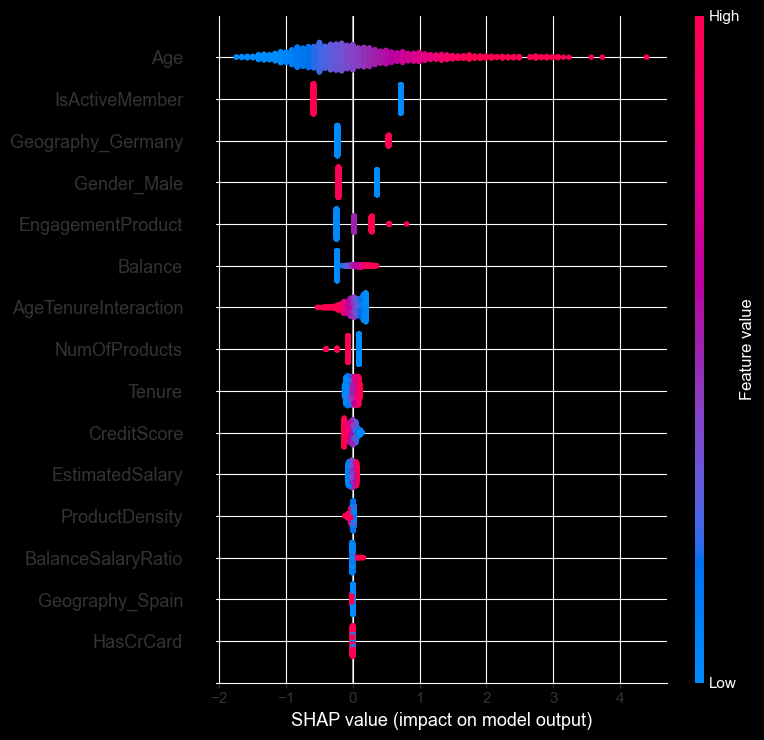

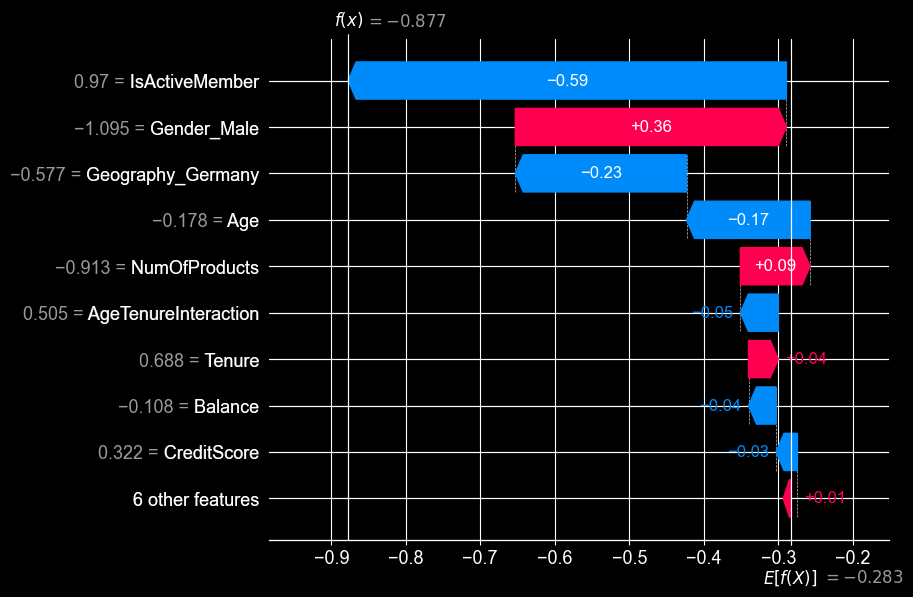

In [27]:

# SHAP Explainability

import shap
import pandas as pd

# Convert scaled arrays to DataFrame (IMPORTANT for feature names)
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Create SHAP explainer (for Logistic Regression)
explainer = shap.Explainer(model, X_train_df)

# Calculate SHAP values
shap_values = explainer(X_test_df)


# Global Explanation
shap.summary_plot(shap_values, X_test_df)


# Local Explanation (1 customer)
shap.plots.waterfall(shap_values[0])

### **PDP (Partial Dependence Plot)**

/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site

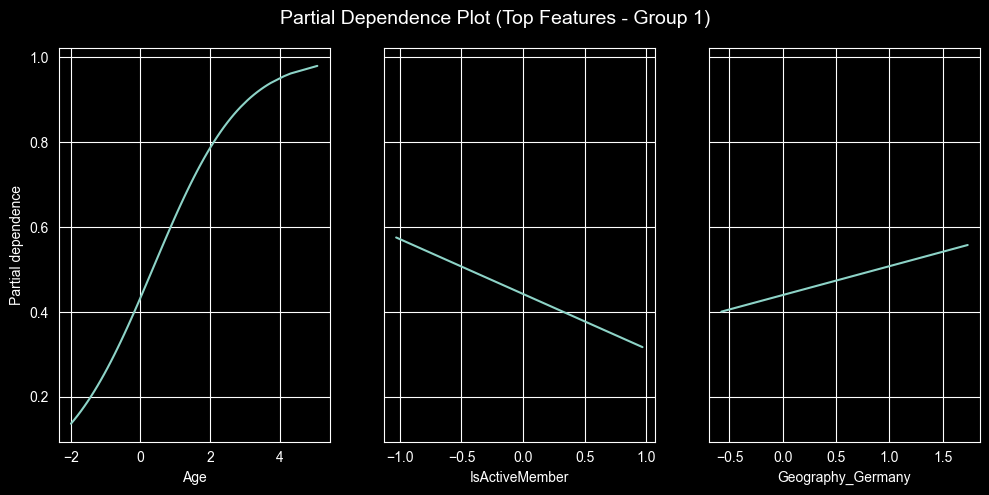

/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/frolt/Desktop/churn_risk_system/.venv/lib/python3.13/site

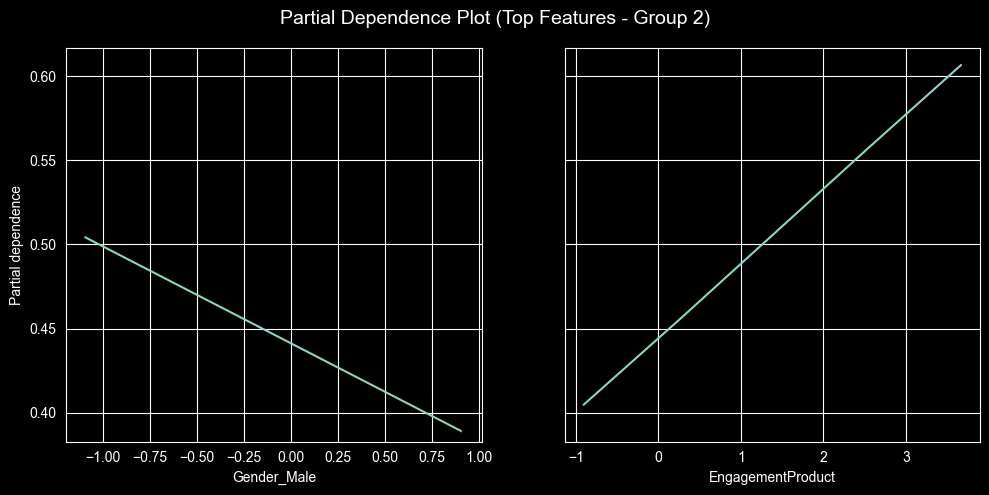

In [35]:
# -----------------------------
# Partial Dependence Plot (PDP)
# -----------------------------
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Use top features from YOUR SHAP plot
features_group_1 = ["Age", "IsActiveMember", "Geography_Germany"]
features_group_2 = ["Gender_Male", "EngagementProduct"]

# -------- Plot 1 --------
fig1, ax1 = plt.subplots(figsize=(10, 5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test_df,   # must be DataFrame with column names
    features_group_1,
    ax=ax1
)

fig1.suptitle("Partial Dependence Plot (Top Features - Group 1)", fontsize=14)
plt.tight_layout()
plt.show()

# -------- Plot 2 --------
fig2, ax2 = plt.subplots(figsize=(10, 5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test_df,
    features_group_2,
    ax=ax2
)

fig2.suptitle("Partial Dependence Plot (Top Features - Group 2)", fontsize=14)
plt.tight_layout()
plt.show()

## **Final Statement**

Logistic Regression was selected as the final model because it achieved the highest recall and the lowest number of false negatives, which is critical for minimizing missed churn customers. While Random Forest and XGBoost provided more balanced performance, they failed to capture as many churn cases. Since the business objective prioritizes identifying at-risk customers over avoiding false alarms, Logistic Regression is the most appropriate choice.